# Zero-Shot Learning with CLIP

This notebook accompanies the Zero-Shot Learning chapter of the Hugging Face Computer Vision Course. It demonstrates how to perform zero-shot image classification using the CLIP (Contrastive Language–Image Pre-training) model from OpenAI, leveraging the `transformers` and `datasets` libraries from Hugging Face.

We will:
1. Load the CLIP model and processor.
2. Load the CUB-200-2011 dataset (Caltech-UCSD Birds-200-2011).
3. Extract class names and define a simulated zero-shot split (seen vs. unseen classes).
4. Prepare text prompts for classification.
5. Perform zero-shot classification on images from unseen classes.
6. Visualize some results.

## 1. Setup

First, let's install and import the necessary libraries.


In [ ]:
# Install necessary libraries

!pip install -q -U transformers datasets torch Pillow matplotlib accelerate torchvision# Import libraries


In [ ]:
# Import libraries
import torch
from transformers import CLIPProcessor, CLIPModel
from datasets import load_dataset
from PIL import Image
import requests
import matplotlib.pyplot as plt
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Load CLIP Model and Processor

We'll load a pre-trained CLIP model (`openai/clip-vit-base-patch32`) and its associated processor from the `transformers` library. The processor handles the necessary image preprocessing (resizing, normalization) and text tokenization required by the CLIP model.

We also check for GPU availability to accelerate computation.

In [ ]:
model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name)

# Check if GPU is available and move model to GPU if it is
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"CLIP model loaded successfully on {device}.")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP model loaded successfully on cuda.



## 3. Load Dataset

We need a dataset for our zero-shot evaluation. We'll use a version of the CUB-200-2011 (Caltech-UCSD Birds-200-2011) dataset available on the Hugging Face Hub.


In [ ]:
# Load the CUB-200-2011 dataset


# Let's load only the test split as we are just evaluating ZSL capability
# and CLIP is already pre-trained.
cub_dataset = load_dataset("cassiekang/cub200_dataset", split='test') # Common split name for test sets
print("Dataset loaded successfully.")
# Let's look at the features
print("Dataset features:", cub_dataset.features)
# And an example
print("Example entry:", cub_dataset[0])


README.md:   0%|          | 0.00/2.87k [00:00<?, ?B/s]

(…)-00000-of-00001-246c29c8515f0b3f.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

(…)-00000-of-00001-575f505f672d6d65.parquet:   0%|          | 0.00/158M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5994 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5794 [00:00<?, ? examples/s]

Dataset loaded successfully.
Dataset features: {'text': Value(dtype='string', id=None), 'image': Image(mode=None, decode=True, id=None)}
Example entry: {'text': 'A photo of a kentucky warbler', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375 at 0x7D0B19903410>}


## 4. Extract Class Names & Define Zero-Shot Split

Since the loaded dataset provides class information within the `text` field, we first need to extract the unique class names (bird species).

After extracting the names, we simulate a zero-shot learning scenario by splitting these classes into two sets:
- **Unseen Classes:** A subset of classes that we pretend the model hasn't been specifically trained on for this task. We will evaluate the model's ability to classify images from these classes.
- **Seen Classes:** The remaining classes. (Note: CLIP was likely pre-trained on data covering *all* these classes, but we define this split to structure our ZSL *evaluation*).


In [ ]:
import re # Import regular expression library

if cub_dataset:
    extracted_class_names = set() # Use a set to automatically store unique names
    # Iterate through the dataset to extract names from the 'text' field
    # Let's process the first N examples for efficiency, assuming they cover most classes
    # Or process the whole dataset if it's small enough
    num_samples_to_check = len(cub_dataset) # Adjust if dataset is very large

    for i in range(num_samples_to_check):
        text_description = cub_dataset[i]['text']
        # Attempt to extract the class name after "a photo of a "
        match = re.search(r'a photo of a (.*)', text_description, re.IGNORECASE)
        if match:
            class_name = match.group(1).strip() # Get the matched group and remove leading/trailing spaces
            extracted_class_names.add(class_name)

    class_names = list(extracted_class_names)
    print(class_names)

['slaty backed gull', 'blue grosbeak', 'hooded merganser', 'field sparrow', 'acadian flycatcher', 'winter wren', 'red breasted merganser', 'bobolink', 'brown thrasher', 'blue winged warbler', 'palm warbler', 'black billed cuckoo', 'green jay', 'loggerhead shrike', 'western grebe', 'least tern', 'seaside sparrow', 'white necked raven', 'house sparrow', 'ruby throated hummingbird', 'cardinal', 'american goldfinch', 'orange crowned warbler', 'marsh wren', 'white throated sparrow', 'american pipit', 'vermilion flycatcher', 'green tailed towhee', 'warbling vireo', 'evening grosbeak', 'elegant tern', 'pacific loon', 'chuck will widow', 'house wren', 'artic tern', 'white eyed vireo', 'barn swallow', 'american crow', 'tree swallow', 'shiny cowbird', 'blue jay', 'hooded oriole', 'forsters tern', 'bohemian waxwing', 'bank swallow', 'western gull', 'sooty albatross', 'cerulean warbler', 'pine warbler', 'sayornis', 'pelagic cormorant', 'black capped vireo', 'red bellied woodpecker', 'red headed wo

In [ ]:
num_classes = len(class_names)
# Make sure we don't request more unseen classes than available
num_unseen = min(50, num_classes // 4) # Let's aim for ~25% unseen, capped at 50
if num_classes < 2:
    print("Error: Need at least 2 classes to perform a split.")
else:
    if num_unseen == 0 and num_classes >= 2:
        num_unseen = 1 # Ensure at least one unseen class if possible
    num_seen = num_classes - num_unseen

    # Shuffle the extracted class names randomly
    shuffled_classes = random.sample(class_names, num_classes)

    # Assign to seen and unseen lists
    unseen_classes = shuffled_classes[:num_unseen]
    seen_classes = shuffled_classes[num_unseen:]

    print(f"\nTotal extracted classes: {num_classes}")
    print(f"Number of 'unseen' classes for ZSL evaluation: {len(unseen_classes)}")
    print(f"Number of 'seen' classes: {len(seen_classes)}")
    # print("\nExample unseen classes:", unseen_classes[:5]) # Uncomment


Total extracted classes: 200
Number of 'unseen' classes for ZSL evaluation: 50
Number of 'seen' classes: 150


## 5. Prepare Text Prompts

CLIP performs classification by comparing an image to a set of text descriptions (prompts). We need to create these prompts for our `unseen_classes`. A common practice is to use a template like "a photo of a [class name]". Using the specific class names from our `unseen_classes` list, we generate the corresponding prompts.




In [ ]:
if cub_dataset and 'unseen_classes' in locals():
    # Create text prompts for the unseen classes
    # Using a common template for better CLIP performance
    prompt_template = "a photo of a {}"
    unseen_class_prompts = [prompt_template.format(c.split('.')[-1].replace('_', ' ')) for c in unseen_classes] # Clean up class names

    print(f"Generated {len(unseen_class_prompts)} prompts for unseen classes.")
    #print("Example prompts:", unseen_class_prompts[:5]) # Uncomment to see some examples
else:
    print("Cannot create prompts because dataset or unseen_classes list is not available.")


Generated 50 prompts for unseen classes.


In [ ]:
if cub_dataset and 'unseen_classes' in locals() and 'unseen_class_prompts' in locals():
    # --- 1. Filter dataset for unseen classes ---
    unseen_indices = []
    original_unseen_class_names = set(unseen_classes) # Use the original names before formatting for prompts

    # Re-extract class names from the 'text' field for filtering
    # This assumes the format "a photo of a class_name"
    for i, item in enumerate(cub_dataset):
        text_desc = item['text']
        match = re.search(r'a photo of a (.*)', text_desc, re.IGNORECASE)
        if match:
            class_name = match.group(1).strip()
            if class_name in original_unseen_class_names:
                 unseen_indices.append(i)
        # else: # Optional: Handle cases where the format might be different
             # print(f"Warning: Could not parse class name from for filtering: {text_desc}")


    if not unseen_indices:
        print("Warning: No images found for the selected unseen classes in the dataset.")
        unseen_subset = []
    else:
        unseen_subset = cub_dataset.select(unseen_indices)
        print(f"Filtered dataset to {len(unseen_subset)} images from unseen classes.")


Filtered dataset to 1451 images from unseen classes.


In [ ]:
num_samples_to_test = min(20, len(unseen_subset)) # Test on 20 samples or fewer if not enough
if num_samples_to_test > 0:
        random_indices = random.sample(range(len(unseen_subset)), num_samples_to_test)
        test_samples = unseen_subset.select(random_indices)
else:
        test_samples = []

results = []
correct_predictions = 0

## 6. Perform Zero-Shot Classification

Now, let's test CLIP's zero-shot capability. We will:
1. Filter our dataset to get only the images corresponding to the `unseen_classes` we defined earlier.
2. Select a random subset of these unseen images to test.
3. For each selected image:
    - Prepare the image using the CLIP processor.
    - Prepare the text prompts *only* for the `unseen_classes`.
    - Feed the image and the unseen class prompts into the CLIP model.
    - The model will output similarity scores (logits) indicating how well the image matches each prompt.
    - Convert these scores to probabilities using softmax.
    - Identify the prompt (and thus the class) with the highest probability as the prediction.
4. Compare the predicted class label with the actual class label for the image.
5. Store the results (image, true label, predicted label) and calculate the overall accuracy on the tested samples.

This process simulates the core ZSL evaluation scenario where the model classifies images from categories it wasn't explicitly trained on (within the context of this specific test, using only prompts from those unseen categories).

In [ ]:
from tqdm.notebook import tqdm # For progress bar
import numpy as np

if cub_dataset and 'unseen_classes' in locals() and 'unseen_class_prompts' in locals():
    # --- 1. Filter dataset for unseen classes ---
    unseen_indices = []
    original_unseen_class_names = set(unseen_classes) # Use the original names before formatting for prompts

    # Re-extract class names from the 'text' field for filtering
    # This assumes the format "a photo of a class_name"
    for i, item in enumerate(cub_dataset):
        text_desc = item['text']
        match = re.search(r'a photo of a (.*)', text_desc, re.IGNORECASE)
        if match:
            class_name = match.group(1).strip()
            if class_name in original_unseen_class_names:
                 unseen_indices.append(i)
        # else: # Optional: Handle cases where the format might be different
             # print(f"Warning: Could not parse class name from for filtering: {text_desc}")


    if not unseen_indices:
        print("Warning: No images found for the selected unseen classes in the dataset.")
        unseen_subset = []
    else:
        unseen_subset = cub_dataset.select(unseen_indices)
        print(f"Filtered dataset to {len(unseen_subset)} images from unseen classes.")

    # --- 2. Select random examples ---
    num_samples_to_test = min(20, len(unseen_subset)) # Test on 20 samples or fewer if not enough
    if num_samples_to_test > 0:
        random_indices = random.sample(range(len(unseen_subset)), num_samples_to_test)
        test_samples = unseen_subset.select(random_indices)
    else:
        test_samples = []

    results = []
    correct_predictions = 0

    # --- 3. Process each example ---
    if test_samples:
        print(f"\nRunning zero-shot classification on {len(test_samples)} samples...")
        for sample in tqdm(test_samples):
            image = sample['image']
            true_text = sample['text']

            # Extract true class name again for comparison
            true_class_name = None
            match = re.search(r'a photo of a (.*)', true_text, re.IGNORECASE)
            if match:
                 true_class_name = match.group(1).strip()

            if image is None or true_class_name is None:
                 print(f"Skipping sample due to missing image or unparsable true class: {true_text}")
                 continue

            # Ensure image is in RGB format for CLIP
            if image.mode != "RGB":
                 image = image.convert("RGB")


            # Prepare inputs
            # Important: Use the `unseen_class_prompts` we generated earlier
            inputs = processor(text=unseen_class_prompts, images=image, return_tensors="pt", padding=True)

            # Move inputs to the correct device
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # Perform inference - no gradient needed for evaluation
            with torch.no_grad():
                outputs = model(**inputs)

            # Get similarity scores (logits per image)
            # These scores measure similarity between the image and each text prompt
            logits_per_image = outputs.logits_per_image

            # Calculate probabilities (softmax) - higher value means higher confidence
            probs = logits_per_image.softmax(dim=1)

            # Get the index of the highest probability
            best_idx = torch.argmax(probs, dim=1).item() # Use .item() to get Python number

            # Map index back to the predicted class name (using unseen_classes list)
            # Note: unseen_class_prompts were derived from unseen_classes, so indices match
            predicted_class_name = unseen_classes[best_idx] # Use the name from the original split list


            # --- 4. Record results ---
            results.append({
                "image": image,
                "true_label": true_class_name,
                "predicted_label": predicted_class_name,
                "confidence_scores": probs.cpu().numpy()[0] # Store probabilities
            })

            # Check if prediction was correct
            if predicted_class_name == true_class_name:
                correct_predictions += 1

        print("Classification finished.")

        # --- (Optional) Calculate Accuracy ---
        if results:
             accuracy = (correct_predictions / len(results)) * 100
             print(f"\nZero-Shot Accuracy on {len(results)} unseen samples: {accuracy:.2f}%")


    else:
        print("No samples selected for testing.")


else:
    print("Cannot perform classification. Prerequisites not met (dataset, unseen classes, or prompts missing).")


Filtered dataset to 1451 images from unseen classes.

Running zero-shot classification on 20 samples...


  0%|          | 0/20 [00:00<?, ?it/s]

Classification finished.

Zero-Shot Accuracy on 20 unseen samples: 70.00%


## 7. Visualize Results

To better understand the performance, let's visualize some of the classification results from the previous step. We will display a few of the test images along with their true labels and the labels predicted by CLIP.

- **Green Title:** Indicates a correct prediction.
- **Red Title:** Indicates an incorrect prediction.

This visual inspection helps provide qualitative insights into the model's ZSL performance on individual examples.

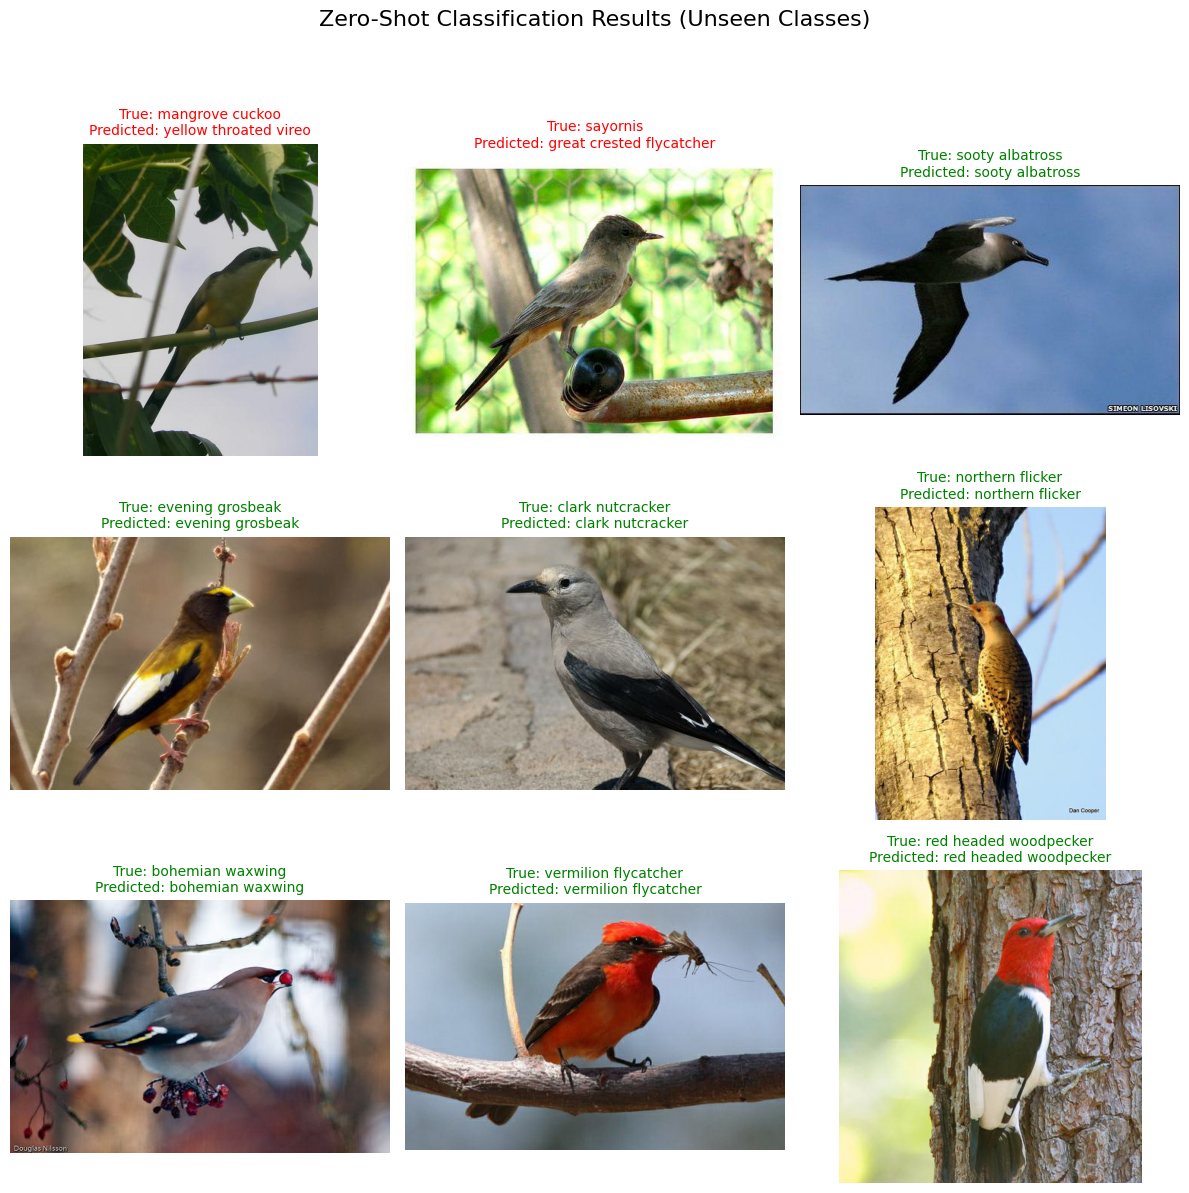

In [ ]:

import math

if 'results' in locals() and results:
    num_results_to_show = min(len(results), 9) # Show up to 9 results

    # Determine grid size (try to make it squarish)
    cols = math.ceil(math.sqrt(num_results_to_show))
    rows = math.ceil(num_results_to_show / cols)

    plt.figure(figsize=(cols * 4, rows * 4)) # Adjust figure size based on grid

    for i in range(num_results_to_show):
        res = results[i]
        image = res['image']
        true_label = res['true_label']
        pred_label = res['predicted_label']

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis('off') # Hide axes

        # Add title - make text red if prediction is wrong
        title_color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPredicted: {pred_label}", color=title_color, fontsize=10)

    plt.suptitle("Zero-Shot Classification Results (Unseen Classes)", fontsize=16, y=1.02) # Add overall title
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()

else:
    print("No classification results available to display.")
    print("Please ensure Cell 7 ran successfully and generated results.")
